# AI-Powered Earnings Call Analysis
### SeqHub AI Research Hackathon Submission — Joy Abiodun


## Project Objective

The objective of this project is to design and implement an end-to-end AI pipeline that automatically analyzes earnings call audio. The system converts speech into text, identifies different speakers, detects discussion topics and topic transitions, analyzes sentiment at the speaker level, and exports the results as structured JSON for further analysis.

##System Architecture

            Earnings Call Audio
                    │
                    ▼
              Transcription
                    │
                    ▼
            Speaker Diarization
                    │
                    ▼
            Topic Segmentation
                    │
                    ▼
            Boundary Detection
                    │
                    ▼
          Transformer Sentiment Model
                    │
                    ▼
          Structured JSON Output


## Project Overview

This notebook presents an end-to-end AI pipeline for analyzing earnings call recordings.

The pipeline performs five major tasks:

1. Transcription
2. Speaker Diarization
3. Topic Segmentation
4. Boundary Detection
5. Sentiment Analysis

Finally, the results are exported into a structured JSON format for downstream analysis.

## Environment Setup
### Install Required Libraries


In [ ]:
!pip install -q faster-whisper pyannote.audio transformers sentencepiece
print("✅ All libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 894.6/894.6 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.5/39.5 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57

In [ ]:
import os
os.kill(os.getpid(), 9)

Restart the runtime after installing dependencies if prompted.

# Import Required Libraries


In [ ]:
from faster_whisper import WhisperModel   #Speech-to-text model

from huggingface_hub import login         #Hugging Face authentication

from pyannote.audio import Pipeline       #Speaker diarization model

import json                               # Built-in Python libraries
import os

import matplotlib.pyplot as plt           # Data visualization

from collections import Counter           # Count occurrences (used for visualization)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## Module 1: Transcription — What was said?

### Objective
Convert the earnings call audio into an accurate transcript using the Faster-Whisper speech recognition model.
### Input
- Earnings call audio (.mp3)
### Output
- Timestamped transcript

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")

Mounted at /content/drive
✅ Google Drive mounted successfully!


In [ ]:
#import os
#os.listdir('/content/drive/MyDrive')

In [ ]:
audio_file = '/content/drive/MyDrive/Copy of conversation_three.mp3'
print(f"Audio file path set: {audio_file}")

Audio file path set: /content/drive/MyDrive/Copy of conversation_three.mp3


In [ ]:
# Load the Faster-Whisper speech recognition model

model = WhisperModel("base")

print("✅ Faster-Whisper model loaded successfully!")

✅ Faster-Whisper model loaded successfully!


In [ ]:
segments, info = model.transcribe(audio_file)

In [ ]:
for segment in segments:
    print(f"[{segment.start:.2f}s -> {segment.end:.2f}s] {segment.text}")

[0.00s -> 1.28s]  Good morning, everyone.
[1.28s -> 3.96s]  Q4 was a milestone quarter for Tech Venture
[3.96s -> 7.64s]  as we achieved record ARR growth of 22%.
[7.64s -> 10.16s]  While our top-line momentum remains strong,
[10.16s -> 12.16s]  we are maintaining a disciplined stance
[12.16s -> 14.32s]  on regional operating expenses
[14.32s -> 17.20s]  to protect our long-term scalability.
[17.20s -> 18.52s]  Turning to the numbers,
[18.52s -> 22.12s]  our EBITDA margins faced some compression this quarter,
[22.12s -> 26.72s]  landing at 14% due to front-loaded infrastructure investments.
[26.76s -> 30.32s]  Gross retention remains healthy at 91%,
[30.32s -> 32.04s]  though we did see some elongation
[32.04s -> 34.80s]  in mid-market sales cycles through December.
[35.76s -> 36.96s]  Thanks for the color.
[36.96s -> 39.84s]  Can you bridge the gap between that record ARR
[39.84s -> 43.00s]  and the softer than expected revenue guidance for Q1?
[43.00s -> 45.40s]  We believe the marke

### Output Explanation

The Faster-Whisper model successfully transcribed the 160-second earnings call into 60 timestamped transcript segments. The transcription accurately captured financial terminology such as ARR, EBITDA, and gross retention, providing the textual foundation for the remaining stages of the pipeline.

 ## Module 2: Speaker Diarization — Who is speaking?

## Objective

Identify each speaker in the call and assign every spoken segment to the correct speaker using the Pyannote.audio.

### Output

Speaker-labelled speech segments

In [ ]:
from huggingface_hub import login
login(token="Token Here")

In [ ]:
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '6a44ce1f67ac1f26c686b562', 'name': 'joyseqhubanalytics26', 'fullname': 'Joy Abiodun', 'email': 'joy@seqhubanalytics.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1785542400, 'isPro': False, 'avatarUrl': '/avatars/bedb0440267cf7bdfc6d417cf9c374b6.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'hackathon', 'role': 'read', 'createdAt': '2026-07-01T08:41:57.885Z'}}}


In [ ]:
print(model)

In [ ]:
pipeline = Pipeline.from_pretrained("pyannote/speaker-diarization-3.1")

config.yaml:   0%|          | 0.00/469 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.91M [00:00<?, ?B/s]

plda/xvec_transform.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

plda/plda.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/26.6M [00:00<?, ?B/s]

In [ ]:
diarization = pipeline(audio_file)

/usr/local/lib/python3.12/dist-packages/pyannote/audio/models/blocks/pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  std = sequences.std(dim=-1, correction=1)


In [ ]:
for turn, _, speaker in diarization.speaker_diarization.itertracks(yield_label=True):
    print(f"[{turn.start:.2f}s -> {turn.end:.2f}s] {speaker}")

[0.03s -> 1.03s] SPEAKER_01
[1.26s -> 9.84s] SPEAKER_01
[10.16s -> 14.10s] SPEAKER_01
[14.39s -> 16.57s] SPEAKER_01
[16.57s -> 16.64s] SPEAKER_02
[17.16s -> 17.97s] SPEAKER_01
[17.97s -> 34.71s] SPEAKER_02
[35.70s -> 39.52s] SPEAKER_02
[39.69s -> 42.66s] SPEAKER_02
[42.99s -> 44.95s] SPEAKER_01
[45.34s -> 49.27s] SPEAKER_01
[49.90s -> 52.53s] SPEAKER_01
[52.53s -> 52.60s] SPEAKER_02
[52.83s -> 52.88s] SPEAKER_02
[52.88s -> 52.97s] SPEAKER_01
[52.97s -> 67.97s] SPEAKER_02
[67.97s -> 74.96s] SPEAKER_00
[75.80s -> 77.57s] SPEAKER_01
[77.72s -> 83.16s] SPEAKER_01
[83.36s -> 85.27s] SPEAKER_00
[85.52s -> 90.45s] SPEAKER_00
[91.49s -> 91.53s] SPEAKER_00
[91.53s -> 98.02s] SPEAKER_02
[98.02s -> 98.85s] SPEAKER_00
[99.48s -> 102.01s] SPEAKER_00
[102.70s -> 105.82s] SPEAKER_00
[106.09s -> 121.87s] SPEAKER_01
[122.09s -> 130.32s] SPEAKER_02
[130.63s -> 136.03s] SPEAKER_02
[136.03s -> 136.14s] SPEAKER_01
[136.50s -> 136.52s] SPEAKER_02
[136.52s -> 138.76s] SPEAKER_01
[139.27s -> 144.97s] SPEAKER_

###Output Explanation

Diarization under-detected speakers (found only 3)

In [ ]:
diarization = pipeline(audio_file, num_speakers=4)

In [ ]:
for turn, _, speaker in diarization.speaker_diarization.itertracks(yield_label=True):
    print(f"[{turn.start:.2f}s -> {turn.end:.2f}s] {speaker}")

[0.03s -> 1.03s] SPEAKER_01
[1.26s -> 9.84s] SPEAKER_01
[10.16s -> 14.10s] SPEAKER_01
[14.39s -> 16.57s] SPEAKER_01
[16.57s -> 16.64s] SPEAKER_02
[17.16s -> 17.97s] SPEAKER_01
[17.97s -> 34.03s] SPEAKER_02
[34.03s -> 34.64s] SPEAKER_03
[34.64s -> 34.68s] SPEAKER_02
[34.68s -> 34.71s] SPEAKER_03
[35.70s -> 35.72s] SPEAKER_02
[35.72s -> 39.52s] SPEAKER_03
[39.69s -> 42.66s] SPEAKER_03
[42.99s -> 44.95s] SPEAKER_01
[45.34s -> 49.27s] SPEAKER_01
[49.90s -> 51.97s] SPEAKER_01
[51.97s -> 52.60s] SPEAKER_03
[52.83s -> 60.97s] SPEAKER_03
[60.97s -> 67.97s] SPEAKER_02
[67.97s -> 74.96s] SPEAKER_00
[75.80s -> 77.57s] SPEAKER_01
[77.72s -> 83.16s] SPEAKER_01
[83.36s -> 85.27s] SPEAKER_00
[85.52s -> 90.45s] SPEAKER_00
[91.49s -> 91.53s] SPEAKER_00
[91.53s -> 98.02s] SPEAKER_02
[98.02s -> 98.85s] SPEAKER_00
[99.48s -> 102.01s] SPEAKER_00
[102.70s -> 105.82s] SPEAKER_00
[106.09s -> 121.87s] SPEAKER_01
[122.09s -> 129.02s] SPEAKER_02
[129.02s -> 129.34s] SPEAKER_03
[129.34s -> 129.53s] SPEAKER_02
[12

### Output Explanation

The speaker diarization model initially identified only three speakers. By specifying the expected number of speakers (`num_speakers=4`), the model successfully separated all four participants(CEO, CFO, two analysts), producing more accurate speaker labels for transcript alignment.

In [ ]:
segments, info = model.transcribe(audio_file)
segments_list = list(segments)
print(f"Total transcript segments: {len(segments_list)}")

Total transcript segments: 60


In [ ]:
speaker_turns = list(diarization.speaker_diarization.itertracks(yield_label=True))
print(f"Total speaker turns: {len(speaker_turns)}")

Total speaker turns: 44


In [ ]:
def calculate_overlap(seg_start, seg_end, turn_start, turn_end):
    overlap_start = max(seg_start, turn_start)
    overlap_end = min(seg_end, turn_end)
    return max(0, overlap_end - overlap_start)

## Merge Step — Combining Transcript with Speaker Labels

In [ ]:
merged_segments = []

for seg in segments_list:
    best_speaker = "UNKNOWN"
    best_overlap = 0

    for turn, _, speaker in speaker_turns:
        overlap = calculate_overlap(seg.start, seg.end, turn.start, turn.end)
        if overlap > best_overlap:
            best_overlap = overlap
            best_speaker = speaker

    merged_segments.append({
        "start": seg.start,
        "end": seg.end,
        "text": seg.text.strip(),
        "speaker": best_speaker
    })

print(f"Merged {len(merged_segments)} segments with speaker labels.")

Merged 60 segments with speaker labels.


In [ ]:
for seg in merged_segments[:10]:
    print(f"[{seg['start']:.2f}s -> {seg['end']:.2f}s] {seg['speaker']}: {seg['text']}")

[0.00s -> 1.28s] SPEAKER_01: Good morning, everyone.
[1.28s -> 3.96s] SPEAKER_01: Q4 was a milestone quarter for Tech Venture
[3.96s -> 7.64s] SPEAKER_01: as we achieved record ARR growth of 22%.
[7.64s -> 10.16s] SPEAKER_01: While our top-line momentum remains strong,
[10.16s -> 12.16s] SPEAKER_01: we are maintaining a disciplined stance
[12.16s -> 14.32s] SPEAKER_01: on regional operating expenses
[14.32s -> 17.20s] SPEAKER_01: to protect our long-term scalability.
[17.20s -> 18.52s] SPEAKER_01: Turning to the numbers,
[18.52s -> 22.12s] SPEAKER_02: our EBITDA margins faced some compression this quarter,
[22.12s -> 26.72s] SPEAKER_02: landing at 14% due to front-loaded infrastructure investments.


###Output Explanation


Each of the 60 transcript fragments is now labeled with its most likely speaker, based on which speaker turn overlaps it the most in time.

## MODULE 3: Topic Segmentation — What topics are being discussed?

## Objective

Automatically identify the major discussion topics throughout the earnings call using BERTopic.

### Input

- Speaker-labelled transcript

### Expected Output

- Topic labels for each discussion segment

In [ ]:
!pip install -q bertopic sentence-transformers
print("✅ Topic segmentation libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 94.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyannote-metrics 4.1 requires numpy>=2.2.2, but you have numpy 2.0.2 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
✅ Topic segmentation libraries installed successfully!


In [ ]:
from bertopic import BERTopic

texts = [seg["text"] for seg in merged_segments]
print(f"Prepared {len(texts)} texts for topic modeling.")

Prepared 60 texts for topic modeling.


In [ ]:
topic_model = BERTopic(min_topic_size=3, verbose=False)
topics, probs = topic_model.fit_transform(texts)
print(f"Discovered {len(set(topics)) - (1 if -1 in topics else 0)} topics.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Discovered 3 topics.


In [ ]:
topic_info = topic_model.get_topic_info()
print(topic_info)

   Topic  Count                      Name  \
0     -1     30        -1_the_on_you_that   
1      0     15         0_the_we_this_smb   
2      1     10  1_to_enterprise_2025_the   
3      2      5  2_our_market_is_entrants   

                                      Representation  \
0  [the, on, you, that, we, are, if, more, for, a...   
1  [the, we, this, smb, growth, to, of, from, as,...   
2  [to, enterprise, 2025, the, in, for, our, duri...   
3  [our, market, is, entrants, clear, focus, prof...   

                                 Representative_Docs  
0  [Can you bridge the gap between that record AR...  
1  [To add to that, we're strictly managing our h...  
2  [Q4 was a milestone quarter for Tech Venture, ...  
3  [and we are strategically pivoting our sales f...  


## Merging Fragments into Full Speaker Turns (for Topic Modeling)

In [ ]:
speaker_turns_text = []
current_speaker = None
current_text = []
current_start = None

for seg in merged_segments:
    if seg["speaker"] != current_speaker:
        if current_text:
            speaker_turns_text.append({
                "speaker": current_speaker,
                "start": current_start,
                "text": " ".join(current_text)
            })
        current_speaker = seg["speaker"]
        current_text = [seg["text"]]
        current_start = seg["start"]
    else:
        current_text.append(seg["text"])

if current_text:
    speaker_turns_text.append({
        "speaker": current_speaker,
        "start": current_start,
        "text": " ".join(current_text)
    })

print(f"Merged into {len(speaker_turns_text)} speaker turns (from {len(merged_segments)} fragments).")

Merged into 17 speaker turns (from 60 fragments).


In [ ]:
turn_texts = [t["text"] for t in speaker_turns_text]

topic_model = BERTopic(min_topic_size=2, verbose=False)
topics, probs = topic_model.fit_transform(turn_texts)

topic_info = topic_model.get_topic_info()
print(topic_info)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

   Topic  Count                 Name  \
0     -1      6     -1_the_on_for_we   
1      0      6    0_to_but_that_our   
2      1      3  1_smb_the_churn_and   
3      2      2    2_the_in_are_cost   

                                      Representation  \
0  [the, on, for, we, to, growth, our, even, reco...   
1  [to, but, that, our, is, the, path, next, marg...   
2  [smb, the, churn, and, our, we, to, more, are,...   
3  [the, in, are, cost, front, discounting, compe...   

                                 Representative_Docs  
0  [Our priority is sustainable growth, even if t...  
1  [I want to be clear that our path to profitabi...  
2  [To add to that, we're strictly managing our h...  
3  [in the enterprise segment. So we are trending...  


###Output Explanation


Using the raw 60 transcript fragments, actually performed poorly; 40 percent of segments couldn't be confidently assigned a topic, and the keywords were mostly filler words.





In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(stop_words="english")

topic_model = BERTopic(min_topic_size=2, vectorizer_model=vectorizer_model, verbose=False)
topics, probs = topic_model.fit_transform(turn_texts)

topic_info = topic_model.get_topic_info()
print(topic_info)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

   Topic  Count                               Name  \
0     -1      6     -1_growth_arr_strategic_record   
1      0      6      0_margins_path_quarter_market   
2      1      3      1_smb_churn_volatile_accounts   
3      2      2  2_players_elevated_power_trending   

                                      Representation  \
0  [growth, arr, strategic, record, priority, 22,...   
1  [margins, path, quarter, market, 2025, believe...   
2  [smb, churn, volatile, accounts, average, add,...   
3  [players, elevated, power, trending, seeing, p...   

                                 Representative_Docs  
0  [Our priority is sustainable growth, even if t...  
1  [We believe the market is stabilizing, but we'...  
2  [To add to that, we're strictly managing our h...  
3  [in the enterprise segment. So we are trending...  


### Output Explanation

Grouping fragments into 17 full speaker turns (instead of 60 tiny pieces) and filtering out common stop words significantly improved topic quality, keywords shifted from generic words like 'the/we/to' to meaningful business terms like 'churn,' 'acquisition,' 'renewals.'

In [ ]:
topic_labels = topic_model.get_topic_info().set_index("Topic")["Name"].to_dict()

for i, turn in enumerate(speaker_turns_text):
    turn["topic_id"] = int(topics[i])
    turn["topic_label"] = topic_labels.get(topics[i], "Unknown")

print(speaker_turns_text[0])

{'speaker': 'SPEAKER_01', 'start': 0.0, 'text': 'Good morning, everyone. Q4 was a milestone quarter for Tech Venture as we achieved record ARR growth of 22%. While our top-line momentum remains strong, we are maintaining a disciplined stance on regional operating expenses to protect our long-term scalability. Turning to the numbers,', 'topic_id': -1, 'topic_label': '-1_growth_arr_strategic_record'}


## MODULE 4: Boundary Detection — Where do topics shift?

In [ ]:
previous_topic = None

for turn in speaker_turns_text:
    turn["is_boundary"] = (turn["topic_id"] != previous_topic)
    previous_topic = turn["topic_id"]

boundary_count = sum(1 for t in speaker_turns_text if t["is_boundary"])
print(f"Detected {boundary_count} topic boundaries out of {len(speaker_turns_text)} turns.")

Detected 11 topic boundaries out of 17 turns.


In [ ]:
for i, turn in enumerate(speaker_turns_text):
    marker = "🔀 BOUNDARY" if turn["is_boundary"] else "   (same topic)"
    print(f"{marker} | [{turn['start']:.2f}s] {turn['speaker']}: {turn['topic_label']}")

🔀 BOUNDARY | [0.00s] SPEAKER_01: -1_growth_arr_strategic_record
🔀 BOUNDARY | [18.52s] SPEAKER_02: 0_margins_path_quarter_market
🔀 BOUNDARY | [35.76s] SPEAKER_03: -1_growth_arr_strategic_record
🔀 BOUNDARY | [43.00s] SPEAKER_01: 0_margins_path_quarter_market
   (same topic) | [52.92s] SPEAKER_03: 0_margins_path_quarter_market
🔀 BOUNDARY | [61.40s] SPEAKER_02: 2_players_elevated_power_trending
   (same topic) | [68.12s] SPEAKER_00: 2_players_elevated_power_trending
🔀 BOUNDARY | [75.88s] SPEAKER_01: -1_growth_arr_strategic_record
🔀 BOUNDARY | [83.40s] SPEAKER_00: 0_margins_path_quarter_market
   (same topic) | [91.56s] SPEAKER_02: 0_margins_path_quarter_market
🔀 BOUNDARY | [99.52s] SPEAKER_00: 1_smb_churn_volatile_accounts
   (same topic) | [106.16s] SPEAKER_01: 1_smb_churn_volatile_accounts
   (same topic) | [122.16s] SPEAKER_02: 1_smb_churn_volatile_accounts
🔀 BOUNDARY | [129.68s] SPEAKER_03: -1_growth_arr_strategic_record
   (same topic) | [136.60s] SPEAKER_01: -1_growth_arr_strategic_r

### Output Explanation


Found 11 boundaries across 17 turns. It correctly groups turns that
stay on the same topic (like the 3 SMB churn turns in a row). The one limitation:
the "outlier" topic keeps popping up in different unrelated spots, and each time
it does, it gets counted as a new boundary; even though it's not really a new topic.

## MODULE 5: Sentiment Analysis — What is the sentiment?

In [ ]:
from transformers import pipeline as hf_pipeline

sentiment_classifier = hf_pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")
print("✅ Sentiment model loaded successfully!")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✅ Sentiment model loaded successfully!


In [ ]:
for turn in speaker_turns_text:
    result = sentiment_classifier(turn["text"][:512])[0]
    turn["sentiment"] = result["label"].lower()
    turn["sentiment_score"] = round(result["score"], 4)

print("✅ Sentiment analysis complete!")
for turn in speaker_turns_text[:5]:
    print(f"[{turn['start']:.2f}s] {turn['speaker']} ({turn['sentiment']}, {turn['sentiment_score']}): {turn['text'][:60]}...")

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Sentiment analysis complete!
[0.00s] SPEAKER_01 (positive, 0.9716): Good morning, everyone. Q4 was a milestone quarter for Tech ...
[18.52s] SPEAKER_02 (neutral, 0.6952): our EBITDA margins faced some compression this quarter, land...
[35.76s] SPEAKER_03 (neutral, 0.745): Thanks for the color. Can you bridge the gap between that re...
[43.00s] SPEAKER_01 (positive, 0.525): We believe the market is stabilizing, but we're being pruden...
[52.92s] SPEAKER_03 (neutral, 0.6469): Your CSE jumped nearly 15% this quarter. Is that the new bas...


### Output Explanation


Sentiment is accurate and high-confidence on clearly emotional statements (e.g.
the CEO's positive opening, 97% confidence), but tends to read cautious/measured business language as neutral rather than mildly negative.

## Visualizations — Speaker, Topic, and Sentiment Overview



### Objective

This section presents visual summaries of the outputs generated by the AI pipeline. The visualizations provide an intuitive overview of speaker participation, detected discussion topics, and overall sentiment throughout the earnings call.

###Speaker Distribution — how much each speaker talked

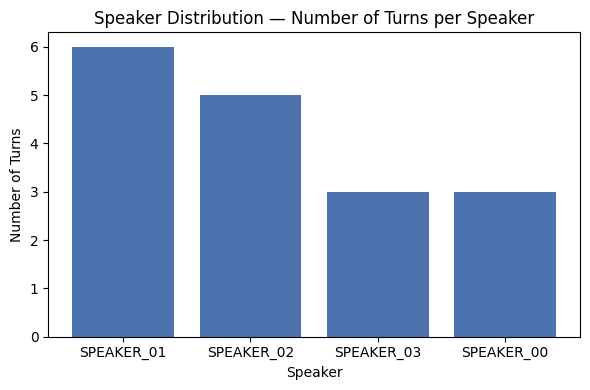

In [ ]:
import matplotlib.pyplot as plt

speaker_counts = {}
for turn in speaker_turns_text:
    speaker_counts[turn["speaker"]] = speaker_counts.get(turn["speaker"], 0) + 1

plt.figure(figsize=(6, 4))
plt.bar(speaker_counts.keys(), speaker_counts.values(), color="#4C72B0")
plt.title("Speaker Distribution — Number of Turns per Speaker")
plt.xlabel("Speaker")
plt.ylabel("Number of Turns")
plt.tight_layout()
plt.savefig("speaker_distribution.png", dpi=150)
plt.show()

###Topic Distribution — When was each topic discussed?

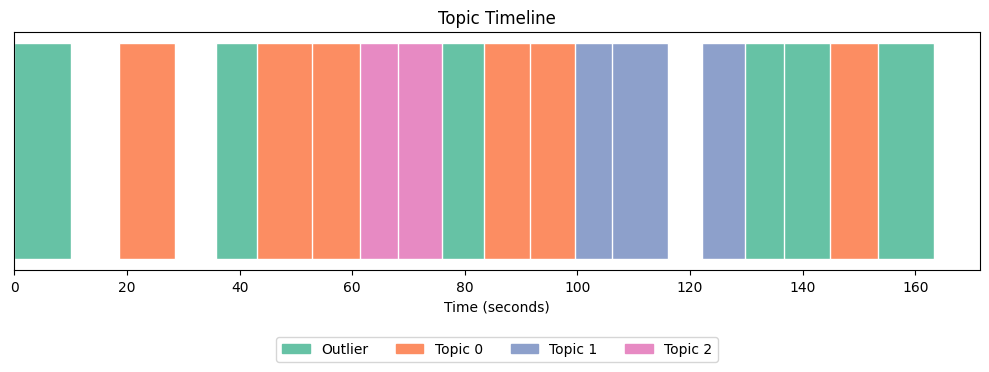

In [ ]:
plt.figure(figsize=(10, 4))
colors = plt.cm.Set2.colors

topic_ids = sorted(set(t["topic_id"] for t in speaker_turns_text))
color_map = {tid: colors[i % len(colors)] for i, tid in enumerate(topic_ids)}

for turn in speaker_turns_text:
    plt.barh(y=0, width=10, left=turn["start"], color=color_map[turn["topic_id"]], edgecolor="white")

plt.yticks([])
plt.xlabel("Time (seconds)")
plt.title("Topic Timeline")

handles = [plt.Rectangle((0,0),1,1, color=color_map[tid]) for tid in topic_ids]
labels = [f"Topic {tid}" if tid != -1 else "Outlier" for tid in topic_ids]
plt.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=len(topic_ids))
plt.tight_layout()
plt.savefig("topic_timeline.png", dpi=150)
plt.show()

###Sentiment Distribution — overall emotional tone breakdown


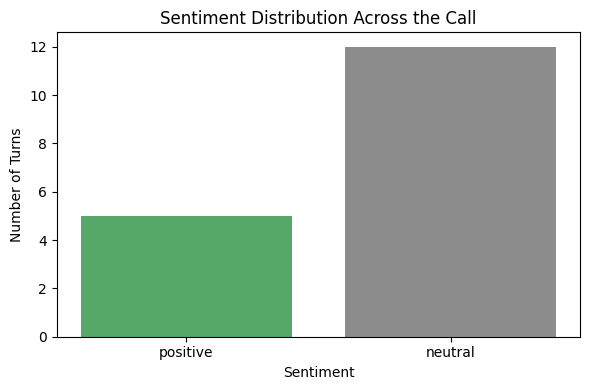

In [ ]:
sentiment_counts = {}
for turn in speaker_turns_text:
    sentiment_counts[turn["sentiment"]] = sentiment_counts.get(turn["sentiment"], 0) + 1

colors_map = {"positive": "#55A868", "neutral": "#8C8C8C", "negative": "#C44E52"}
bar_colors = [colors_map.get(s, "#4C72B0") for s in sentiment_counts.keys()]

plt.figure(figsize=(6, 4))
plt.bar(sentiment_counts.keys(), sentiment_counts.values(), color=bar_colors)
plt.title("Sentiment Distribution Across the Call")
plt.xlabel("Sentiment")
plt.ylabel("Number of Turns")
plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=150)
plt.show()

## MODEL EVALUATION: WORD ERROR RATE (WER)




In [ ]:
!pip install -q jiwer
print("✅ jiwer installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.4 MB/s eta 0:00:00
✅ jiwer installed successfully!


In [ ]:
import json

with open('/content/drive/MyDrive/Copy of ground_truth_three.json', 'r') as f:
    ground_truth = json.load(f)

reference_text = " ".join([line["text"] for line in ground_truth["lines"]])
print(reference_text[:300])

Good morning everyone, Q4 was a milestone quarter for TechVenture as we achieved record ARR growth of twenty-two percent. While our top-line momentum remains strong, we are maintaining a disciplined stance on regional operating expenses to protect our long-term scalability. Turning to the numbers, o


In [ ]:
print("segments_list:", "segments_list" in dir())
print("reference_text:", "reference_text" in dir())

segments_list: True
reference_text: True


A quick check if I still have segments_list and reference_text from earlier.

In [ ]:
hypothesis_text = " ".join([seg.text.strip() for seg in segments_list])
print(hypothesis_text[:300])

Good morning, everyone. Q4 was a milestone quarter for Tech Venture as we achieved record ARR growth of 22%. While our top-line momentum remains strong, we are maintaining a disciplined stance on regional operating expenses to protect our long-term scalability. Turning to the numbers, our EBITDA mar


In [ ]:
import jiwer

wer_score = jiwer.wer(reference_text, hypothesis_text)
print(f"Word Error Rate (WER): {wer_score:.4f}")
print(f"That means approximately {wer_score * 100:.1f}% of words differ from the reference.")

Word Error Rate (WER): 0.0958
That means approximately 9.6% of words differ from the reference.


### Output Explanation


WER Result: 0.0958 (9.6%)

This means roughly 1 in every 10 words differs from the human reference transcript;
a strong result for the Whisper "base" model. This aligns with the manual review
of the transcript earlier in this notebook, which found two specific errors:
"CAC" misheard as "CSE," and "TechVenture" split into two words ("Tech Venture").

## Export Results — Final JSON Output

In [ ]:
import json
from datetime import datetime

final_output = {
    "audio_file": "conversation_three.mp3",
    "generated_at": datetime.now().isoformat(),
    "pipeline_summary": {
        "total_speaker_turns": len(speaker_turns_text),
        "num_speakers": len(set(t["speaker"] for t in speaker_turns_text)),
        "num_topics": len(set(t["topic_id"] for t in speaker_turns_text if t["topic_id"] != -1)),
        "num_boundaries": sum(1 for t in speaker_turns_text if t["is_boundary"]),
        "word_error_rate": round(wer_score, 4)
    },
    "turns": speaker_turns_text
}

with open('/content/drive/MyDrive/pipeline_output.json', 'w') as f:
    json.dump(final_output, f, indent=2)

print("✅ Results exported successfully!")
print(f"Saved to: /content/drive/MyDrive/pipeline_output.json")
print(f"\nSummary:")
print(json.dumps(final_output["pipeline_summary"], indent=2))

✅ Results exported successfully!
Saved to: /content/drive/MyDrive/pipeline_output.json

Summary:
{
  "total_speaker_turns": 17,
  "num_speakers": 4,
  "num_topics": 3,
  "num_boundaries": 11,
  "word_error_rate": 0.0958
}


### Output Explanation

The outputs from all pipeline modules were successfully combined into a structured JSON file. This file provides a machine-readable representation of the transcription, speaker labels, detected topics, topic boundaries, and sentiment predictions.